### 1. What is a Support Vector Machine (SVM)?

A Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It finds the optimal hyperplane that best separates data into classes by maximizing the margin between data points of different classes.

### 2. What is the difference between Hard Margin and Soft Margin SVM?

Hard Margin SVM: assumes that the data is linearly separable without errors and finds a hyperplane with the maximum margin and no misclassifications.

Soft Margin SVM:  allows some misclassifications to improve generalization for non-separable data by introducing a penalty term controlled by the parameter

### 3. What is the mathematical intuition behind SVM?

The mathematical foundation of SVM revolves around optimizing the hyperplane's position to maximize the margin while considering the support vectors. This approach ensures robust classification performance, even in complex datasets, by leveraging the power of kernels for non-linear separability.

### 4. What is the role of Lagrange Multipliers in SVM?

Lagrange Multipliers help transform the constrained optimization problem of SVM into a dual form, making it easier to solve and enabling the use of kernel functions to handle non-linear data.

### 5. What are Support Vectors in SVM?

Support Vectors are the data points that lie closest to the hyperplane and define the margin. They are critical because the optimal hyperplane depends only on these points.

### 6. What is a Support Vector Classifier (SVC)?

SVC is the implementation of SVM for classification problems. It finds the best hyperplane that separates different classes with the largest possible margin.

### 7. What is a Support Vector Regressor (SVR)?

SVR applies the principles of SVM to regression problems. It finds a function that deviates from the actual target values by a value no more than $\epsilon$, while maintaining flatness (small weights).

### 8. What is the Kernel Trick in SVM?

The Kernel Trick allows SVM to perform non-linear classification by implicitly mapping input features into a higher-dimensional space using kernel functions (e.g., RBF, polynomial) without computing the transformation explicitly.

### 9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel:

Linear Kernel: Used when data is linearly separable; faster and simpler.
Polynomial Kernel: Captures interactions between features using polynomial degrees; suitable for moderate non-linearities.
RBF (Radial Basis Function) Kernel: Handles highly non-linear data; maps data to infinite-dimensional space using Gaussian function.

### 10. What is the effect of the C parameter in SVM?

The C parameter controls the trade-off between maximizing the margin and minimizing classification error. A small C increases margin (more tolerance to misclassification), while a large C aims for fewer misclassifications (narrower margin).

### 11. What is the role of the Gamma parameter in RBF Kernel SVM?

Gamma defines the influence of a single training example. A low gamma means far influence (smoother decision boundary), while high gamma means close influence (more complex boundary, possible overfitting).


### 12. What is the Naïve Bayes classifier, and why is it called "Naïve"?

 Naïve Bayes is a probabilistic classifier based on Bayes' Theorem assuming independence between features. It is called "naïve" because it assumes all features are conditionally independent given the class label, which is rarely true in reality.

### 13. What is Bayes’ Theorem?

Bayes' Theorem describes the probability of a hypothesis given observed evidence:

$$
P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}
$$


### 14. Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes:

Gaussian NB: Assumes continuous data follows a normal distribution.
Multinomial NB: Works with discrete count features like word counts in documents.
Bernoulli NB: Works with binary/boolean features indicating presence or absence of a feature.

### 15. When should you use Gaussian Naïve Bayes over other variants?

Use Gaussian Naïve Bayes when the features are continuous and approximately normally distributed (e.g., medical or sensor data).

### 16. What are the key assumptions made by Naïve Bayes?

Features are conditionally independent given the class label.
Each feature contributes equally and independently to the outcome.

### 17. What are the advantages and disadvantages of Naïve Bayes?

Advantages: Fast, simple, works well with high-dimensional data, performs well with small data.
Disadvantages: Assumes feature independence (often unrealistic), may underperform when features are highly correlated.

### 18. Why is Naïve Bayes a good choice for text classification?

Because text data typically has a high number of features (words), which are often conditionally independent. Naïve Bayes is efficient, effective, and handles high-dimensional sparse data well.

### 19. Compare SVM and Naïve Bayes for classification tasks:

SVM: Better accuracy for complex data, handles non-linear boundaries, more computationally intensive.
Naïve Bayes: Faster, better with small or high-dimensional data, especially good for text classification.
Use SVM when accuracy matters; use Naïve Bayes for speed or when assumptions are met.

### 20. How does Laplace Smoothing help in Naïve Bayes?

Laplace Smoothing (adding 1 to word counts) prevents zero probabilities for unseen features in test data, which can otherwise nullify the entire probability product in Naïve Bayes.

# Practical

### 21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM classifier
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Accuracy (Iris):", accuracy_score(y_test, y_pred))


Accuracy (Iris): 1.0


### 22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies:

In [2]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
wine = datasets.load_wine()
X, y = wine.data, wine.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Linear SVM
linear_svc = SVC(kernel='linear')
linear_svc.fit(X_train, y_train)
linear_acc = accuracy_score(y_test, linear_svc.predict(X_test))

# RBF SVM
rbf_svc = SVC(kernel='rbf')
rbf_svc.fit(X_train, y_train)
rbf_acc = accuracy_score(y_test, rbf_svc.predict(X_test))

print("Linear Kernel Accuracy:", linear_acc)
print("RBF Kernel Accuracy:", rbf_acc)


Linear Kernel Accuracy: 0.9814814814814815
RBF Kernel Accuracy: 0.7592592592592593


### 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE):

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load data
data = fetch_california_housing()
X, y = data.data, data.target

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

# Predict and evaluate
y_pred = svr.predict(X_test)
print("Mean Squared Error (Housing):", mean_squared_error(y_test, y_pred))


Mean Squared Error (Housing): 0.34705834034323335


### 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary:

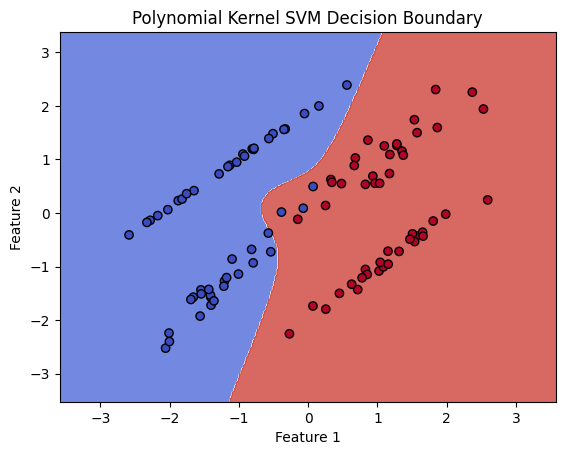

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# Create synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=42)

# Train SVM with polynomial kernel
clf = SVC(kernel='poly', degree=3)
clf.fit(X, y)

# Plot decision boundary
def plot_decision_boundary(X, y, model):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title("Polynomial Kernel SVM Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(X, y, clf)


### 25.  Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy:

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict and evaluate
y_pred = gnb.predict(X_test)
print("Accuracy (Breast Cancer):", accuracy_score(y_test, y_pred))


Accuracy (Breast Cancer): 0.9415204678362573


### 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.

In [28]:
# Import necessary libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load the 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Split the dataset into features and target labels
X = newsgroups.data
y = newsgroups.target

# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text data into a matrix of token counts
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Create and train the Multinomial Naïve Bayes classifier
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test_counts)

# Evaluate the model
accuracy = metrics.accuracy_score(y_test, y_pred)
classification_report = metrics.classification_report(y_test, y_pred, target_names=newsgroups.target_names)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report)


Accuracy: 0.6175

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.61      0.25      0.36       151
           comp.graphics       0.48      0.75      0.58       202
 comp.os.ms-windows.misc       0.73      0.04      0.08       195
comp.sys.ibm.pc.hardware       0.53      0.73      0.62       183
   comp.sys.mac.hardware       0.86      0.58      0.69       205
          comp.windows.x       0.68      0.80      0.74       215
            misc.forsale       0.88      0.53      0.66       193
               rec.autos       0.87      0.63      0.73       196
         rec.motorcycles       0.49      0.58      0.53       168
      rec.sport.baseball       0.99      0.67      0.80       211
        rec.sport.hockey       0.92      0.80      0.86       198
               sci.crypt       0.59      0.77      0.67       201
         sci.electronics       0.84      0.49      0.62       202
                 sci.med       0.

### 27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually=

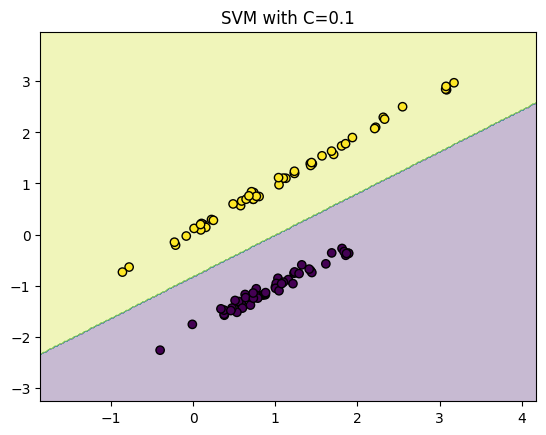

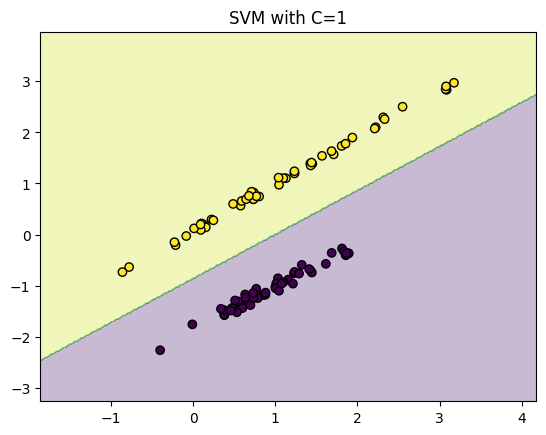

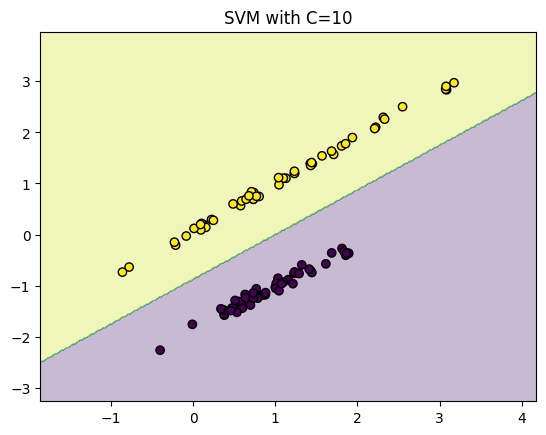

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load data
X, y = datasets.make_classification(n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, random_state=42)

# Plot decision boundary
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

# Compare with different C values
for C in [0.1, 1, 10]:
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)
    plot_decision_boundary(clf, X, y, f"SVM with C={C}")


### 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features

In [9]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Generate binary dataset
X = np.random.randint(2, size=(1000, 10))
y = np.random.randint(2, size=1000)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)

print("Accuracy (BernoulliNB):", accuracy_score(y_test, y_pred))


Accuracy (BernoulliNB): 0.484


### 29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load and split
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Without scaling
clf_unscaled = SVC()
clf_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, clf_unscaled.predict(X_test))

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
clf_scaled = SVC()
clf_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, clf_scaled.predict(X_test_scaled))

print("Accuracy (Unscaled):", acc_unscaled)
print("Accuracy (Scaled):", acc_scaled)


Accuracy (Unscaled): 1.0
Accuracy (Scaled): 1.0


### 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standard GaussianNB (no Laplace smoothing)
model1 = GaussianNB()
model1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, model1.predict(X_test))

# Laplace smoothing simulated (not native to GaussianNB; for categorical features only)
print("Accuracy without Laplace Smoothing:", acc1)
print("Laplace smoothing is not applicable to GaussianNB (works with continuous data).")


Accuracy without Laplace Smoothing: 0.958041958041958
Laplace smoothing is not applicable to GaussianNB (works with continuous data).


### 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel)

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_wine
from sklearn.svm import SVC

X, y = load_wine(return_X_y=True)
params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}

grid = GridSearchCV(SVC(), params, cv=5)
grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)


Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best score: 0.961111111111111


### 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy=

In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = make_classification(n_classes=2, weights=[0.9, 0.1], n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Without class weights
model1 = SVC()
model1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, model1.predict(X_test))

# With class weights
model2 = SVC(class_weight='balanced')
model2.fit(X_train, y_train)
acc2 = accuracy_score(y_test, model2.predict(X_test))

print("Accuracy without class weighting:", acc1)
print("Accuracy with class weighting:", acc2)


Accuracy without class weighting: 0.908
Accuracy with class weighting: 0.916


### 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Example data (real project should load from dataset)
emails = ["Free money now!", "Hi, are we still meeting today?", "Win a new car!", "Let's schedule our call"]
labels = [1, 0, 1, 0]  # 1 = spam, 0 = not spam

X_train, X_test, y_train, y_test = train_test_split(emails, labels, test_size=0.5, random_state=42)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print("Accuracy (Spam Detection):", accuracy_score(y_test, y_pred))


Accuracy (Spam Detection): 0.0


### 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

svm = SVC()
nb = GaussianNB()

svm.fit(X_train, y_train)
nb.fit(X_train, y_train)

print("SVM Accuracy:", accuracy_score(y_test, svm.predict(X_test)))
print("Naïve Bayes Accuracy:", accuracy_score(y_test, nb.predict(X_test)))


SVM Accuracy: 1.0
Naïve Bayes Accuracy: 1.0


### 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results

In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Without feature selection
model = GaussianNB()
model.fit(X_train, y_train)
acc_all = accuracy_score(y_test, model.predict(X_test))

# With feature selection
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y, random_state=42)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)
acc_selected = accuracy_score(y_test2, model2.predict(X_test2))

print("Accuracy (All features):", acc_all)
print("Accuracy (Selected features):", acc_selected)


Accuracy (All features): 0.958041958041958
Accuracy (Selected features): 0.951048951048951


### 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy

In [17]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

ovr = OneVsRestClassifier(SVC())
ovo = OneVsOneClassifier(SVC())

ovr.fit(X_train, y_train)
ovo.fit(X_train, y_train)

print("OvR Accuracy:", accuracy_score(y_test, ovr.predict(X_test)))
print("OvO Accuracy:", accuracy_score(y_test, ovo.predict(X_test)))


OvR Accuracy: 0.7111111111111111
OvO Accuracy: 0.7777777777777778


### 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

for kernel in ['linear', 'poly', 'rbf']:
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"Kernel = {kernel}, Accuracy = {acc}")


Kernel = linear, Accuracy = 0.958041958041958
Kernel = poly, Accuracy = 0.9440559440559441
Kernel = rbf, Accuracy = 0.951048951048951


### 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.datasets import load_iris
import numpy as np

X, y = load_iris(return_X_y=True)
skf = StratifiedKFold(n_splits=5)

scores = cross_val_score(SVC(), X, y, cv=skf)
print("Cross-validation scores:", scores)
print("Average accuracy:", np.mean(scores))


Cross-validation scores: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Average accuracy: 0.9666666666666666


### 39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

for prior in [[0.5, 0.5], [0.3, 0.7], [0.7, 0.3]]:
    model = GaussianNB(priors=prior)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Priors = {prior}, Accuracy = {acc}")


Priors = [0.5, 0.5], Accuracy = 0.958041958041958
Priors = [0.3, 0.7], Accuracy = 0.958041958041958
Priors = [0.7, 0.3], Accuracy = 0.951048951048951


### 40 Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train with all features
model_full = SVC()
model_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

# Recursive Feature Elimination
rfe = RFE(estimator=SVC(kernel="linear"), n_features_to_select=10)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

model_rfe = SVC()
model_rfe.fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, model_rfe.predict(X_test_rfe))

print("Accuracy (All features):", acc_full)
print("Accuracy (RFE-selected features):", acc_rfe)


Accuracy (All features): 0.951048951048951
Accuracy (RFE-selected features): 0.958041958041958


### 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy

In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



### 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss)

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)

loss = log_loss(y_test, y_proba)
print("Log Loss:", loss)


Log Loss: 0.5041791651287795


### 43.  Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn

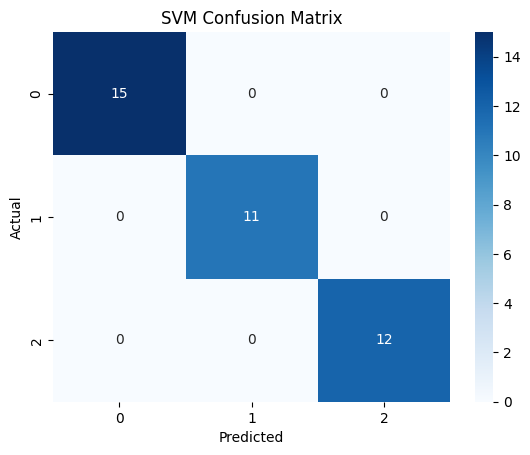

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE

In [25]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

regressor = SVR()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (SVR):", mae)


Mean Absolute Error (SVR): 0.8674205743031638


### 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score

In [26]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", auc)


ROC-AUC Score: 0.9935497295047857


### 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve

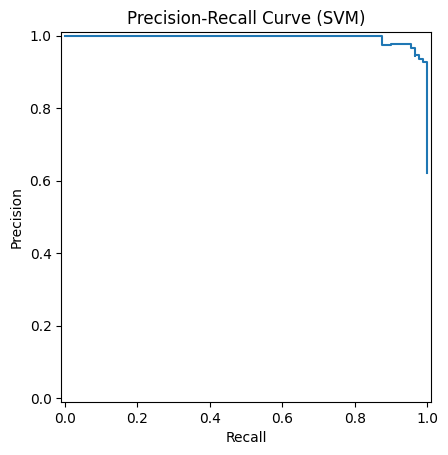

In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = SVC(probability=True)
clf.fit(X_train, y_train)
y_scores = clf.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.title("Precision-Recall Curve (SVM)")
plt.show()
